# Improved Turbofan Engine RUL Prediction (FD001)

Improvements:
- Removes low-variance features
- Creates capped RUL target (125 cycles)
- Standardizes features
- Uses XGBoost Regressor
- Evaluates with MAE, RMSE, R²
- Feature importance visualization


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor


In [2]:
train_path='train_FD001.txt'
test_path='test_FD001.txt'
rul_path='RUL_FD001.txt'


In [3]:
import os

print("Current Folder:")
print(os.getcwd())

print("\nFiles/Folders:")
print(os.listdir())

Current Folder:
c:\Users\priya_vk383uf\OneDrive\Desktop\Turbofan-RUL-Prediction

Files/Folders:
['app.py', 'dataset', 'requirements.txt', 'scaler.pkl', 'screenshots', 'selector.pkl', 'Turbofan_RUL_XGBoost_Improved.ipynb', 'xgboost_rul_model.pkl']


In [4]:
import os

print(os.listdir("dataset"))

['RUL_FD001.txt', 'test_FD001.txt', 'train_FD001.txt']


In [5]:
import os

train_path = "dataset/train_FD001.txt"
test_path = "dataset/test_FD001.txt"
rul_path = "dataset/RUL_FD001.txt"

print("Train Exists:", os.path.exists(train_path))
print("Test Exists :", os.path.exists(test_path))
print("RUL Exists  :", os.path.exists(rul_path))

Train Exists: True
Test Exists : True
RUL Exists  : True


In [6]:
train_path = "dataset/train_FD001.txt"
test_path = "dataset/test_FD001.txt"
rul_path = "dataset/RUL_FD001.txt"

In [7]:
cols=['engine_id','cycle']+[f'op_setting_{i}' for i in range(1,4)]+[f'sensor_{i}' for i in range(1,22)]

train_df=pd.read_csv(train_path,sep=r'\s+',header=None).iloc[:,:26]
train_df.columns=cols

test_df=pd.read_csv(test_path,sep=r'\s+',header=None).iloc[:,:26]
test_df.columns=cols

rul_df=pd.read_csv(rul_path,header=None,names=['RUL'])


In [8]:
max_cycle=train_df.groupby('engine_id')['cycle'].max().reset_index()
max_cycle.columns=['engine_id','max_cycle']

train_df=train_df.merge(max_cycle,on='engine_id')
train_df['RUL']=train_df['max_cycle']-train_df['cycle']

# RUL clipping (common CMAPSS practice)
train_df['RUL']=train_df['RUL'].clip(upper=125)


In [9]:
features=[c for c in train_df.columns if c.startswith('sensor_') or c.startswith('op_setting_')]

X_train=train_df[features]
y_train=train_df['RUL']

test_last=test_df.groupby('engine_id').last().reset_index()
X_test=test_last[features]
y_test=rul_df['RUL']


In [10]:
selector=VarianceThreshold(threshold=0.0001)

X_train=selector.fit_transform(X_train)
X_test=selector.transform(X_test)

scaler=StandardScaler()

X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)


In [11]:
model=XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train,y_train)

preds=model.predict(X_test)


In [12]:
mae=mean_absolute_error(y_test,preds)
rmse=np.sqrt(mean_squared_error(y_test,preds))
r2=r2_score(y_test,preds)

print('MAE :',round(mae,2))
print('RMSE:',round(rmse,2))
print('R2  :',round(r2,2))


MAE : 12.97
RMSE: 17.78
R2  : 0.82


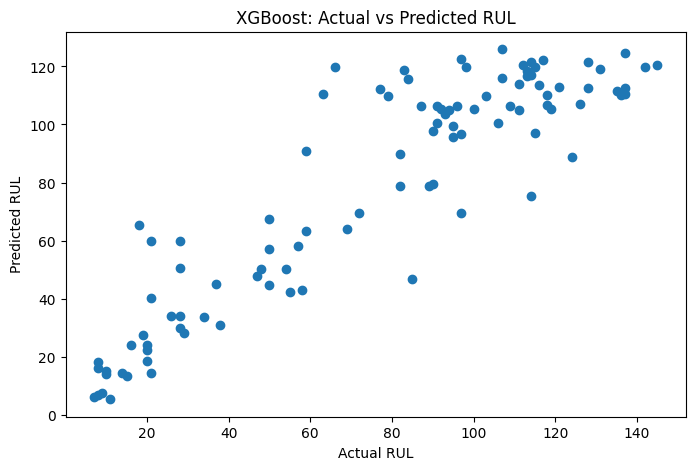

In [13]:
plt.figure(figsize=(8,5))
plt.scatter(y_test,preds)
plt.xlabel('Actual RUL')
plt.ylabel('Predicted RUL')
plt.title('XGBoost: Actual vs Predicted RUL')
plt.show()


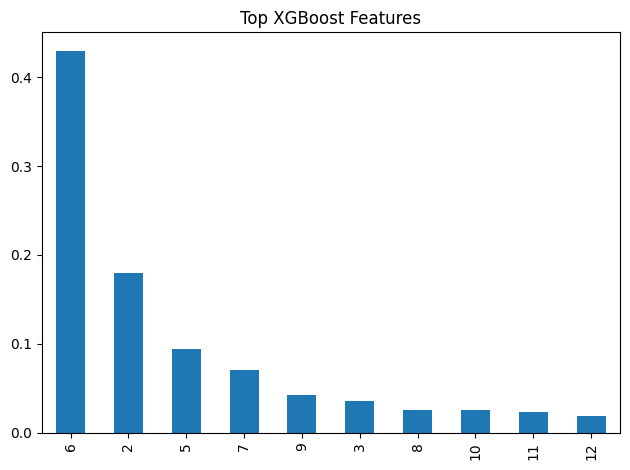

In [14]:
importance=pd.Series(model.feature_importances_)
importance.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title('Top XGBoost Features')
plt.tight_layout()
plt.show()


In [15]:
import joblib

joblib.dump(scaler, "scaler.pkl")
joblib.dump(selector, "selector.pkl")

print("All files saved successfully")

All files saved successfully


In [16]:
test_last = test_df.groupby('engine_id').last().reset_index()

test_last.head()

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,31,-0.0006,0.0004,100.0,518.67,642.58,1581.22,1398.91,14.62,...,521.79,2388.06,8130.11,8.4024,0.03,393,2388,100.0,38.81,23.3552
1,2,49,0.0018,-0.0001,100.0,518.67,642.55,1586.59,1410.83,14.62,...,521.74,2388.09,8126.90,8.4505,0.03,391,2388,100.0,38.81,23.2618
2,3,126,-0.0016,0.0004,100.0,518.67,642.88,1589.75,1418.89,14.62,...,520.83,2388.14,8131.46,8.4119,0.03,395,2388,100.0,38.93,23.2740
3,4,106,0.0012,0.0004,100.0,518.67,642.78,1594.53,1406.88,14.62,...,521.88,2388.11,8133.64,8.4634,0.03,395,2388,100.0,38.58,23.2581
4,5,98,-0.0013,-0.0004,100.0,518.67,642.27,1589.94,1419.36,14.62,...,521.00,2388.15,8125.74,8.4362,0.03,394,2388,100.0,38.75,23.4117


In [17]:
preds[:10]

array([120.54868 , 119.946335,  63.9017  ,  89.71313 , 106.43575 ,
       103.53127 , 100.644684,  99.54846 , 105.02619 , 106.246574],
      dtype=float32)

In [18]:
test_last.iloc[0][features]

op_setting_1      -0.0006
op_setting_2       0.0004
op_setting_3     100.0000
sensor_1         518.6700
sensor_2         642.5800
sensor_3        1581.2200
sensor_4        1398.9100
sensor_5          14.6200
sensor_6          21.6100
sensor_7         554.4200
sensor_8        2388.0800
sensor_9        9056.4000
sensor_10          1.3000
sensor_11         47.2300
sensor_12        521.7900
sensor_13       2388.0600
sensor_14       8130.1100
sensor_15          8.4024
sensor_16          0.0300
sensor_17        393.0000
sensor_18       2388.0000
sensor_19        100.0000
sensor_20         38.8100
sensor_21         23.3552
Name: 0, dtype: float64

In [19]:
sample = pd.DataFrame([test_last.iloc[0][features]])

selected = selector.transform(sample)
scaled = scaler.transform(selected)

model.predict(scaled)

array([120.54868], dtype=float32)

In [20]:
test_last = test_df.groupby('engine_id').last().reset_index()

features=[c for c in train_df.columns
          if c.startswith('sensor_')
          or c.startswith('op_setting_')]

sample = pd.DataFrame([test_last.iloc[0][features]])

selected = selector.transform(sample)
scaled = scaler.transform(selected)

pred = model.predict(scaled)[0]

print(pred)
print(sample)

120.54868
   op_setting_1  op_setting_2  op_setting_3  sensor_1  sensor_2  sensor_3  \
0       -0.0006        0.0004         100.0    518.67    642.58   1581.22   

   sensor_4  sensor_5  sensor_6  sensor_7  ...  sensor_12  sensor_13  \
0   1398.91     14.62     21.61    554.42  ...     521.79    2388.06   

   sensor_14  sensor_15  sensor_16  sensor_17  sensor_18  sensor_19  \
0    8130.11     8.4024       0.03      393.0     2388.0      100.0   

   sensor_20  sensor_21  
0      38.81    23.3552  

[1 rows x 24 columns]


In [21]:
import joblib

joblib.dump(model, "xgboost_rul_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(selector, "selector.pkl")

print("Artifacts re-saved")

Artifacts re-saved


In [22]:
import joblib

loaded_model = joblib.load("xgboost_rul_model.pkl")
loaded_scaler = joblib.load("scaler.pkl")
loaded_selector = joblib.load("selector.pkl")

sample = pd.DataFrame([test_last.iloc[0][features]])

selected = loaded_selector.transform(sample)
scaled = loaded_scaler.transform(selected)

pred = loaded_model.predict(scaled)[0]

print(pred)

120.54868


In [23]:
import joblib

loaded_model = joblib.load("xgboost_rul_model.pkl")
loaded_scaler = joblib.load("scaler.pkl")
loaded_selector = joblib.load("selector.pkl")

sample = pd.DataFrame([test_last.iloc[0][features]])

selected = loaded_selector.transform(sample)
scaled = loaded_scaler.transform(selected)

print(loaded_model.predict(scaled)[0])

120.54868


In [24]:
print(features)

['op_setting_1', 'op_setting_2', 'op_setting_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21']


In [25]:
print(test_last.iloc[0][features])

op_setting_1      -0.0006
op_setting_2       0.0004
op_setting_3     100.0000
sensor_1         518.6700
sensor_2         642.5800
sensor_3        1581.2200
sensor_4        1398.9100
sensor_5          14.6200
sensor_6          21.6100
sensor_7         554.4200
sensor_8        2388.0800
sensor_9        9056.4000
sensor_10          1.3000
sensor_11         47.2300
sensor_12        521.7900
sensor_13       2388.0600
sensor_14       8130.1100
sensor_15          8.4024
sensor_16          0.0300
sensor_17        393.0000
sensor_18       2388.0000
sensor_19        100.0000
sensor_20         38.8100
sensor_21         23.3552
Name: 0, dtype: float64


In [28]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

# Random Forest
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

# RF Metrics
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

# XGBoost Metrics
xgb_mae = mean_absolute_error(y_test, preds)
xgb_rmse = np.sqrt(mean_squared_error(y_test, preds))
xgb_r2 = r2_score(y_test, preds)

# Comparison Table
comparison = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "MAE": [round(rf_mae, 2), round(xgb_mae, 2)],
    "RMSE": [round(rf_rmse, 2), round(xgb_rmse, 2)],
    "R2 Score": [round(rf_r2, 2), round(xgb_r2, 2)]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Random Forest,13.21,18.14,0.81
1,XGBoost,12.97,17.78,0.82


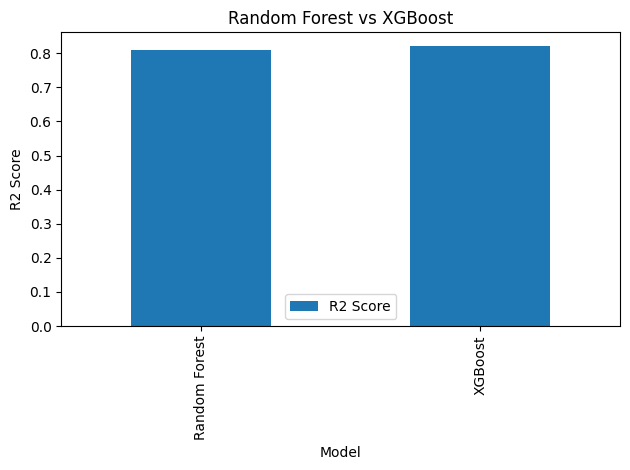

In [29]:
import matplotlib.pyplot as plt

comparison.set_index("Model")[["R2 Score"]].plot(kind="bar")

plt.title("Random Forest vs XGBoost")
plt.ylabel("R2 Score")
plt.tight_layout()
plt.show()